# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dwi Cahyawati
- **Email:** dwicahyawati@mail.ugm.ac.id
- **ID Dicoding:** dwi_cahyawati_my5V

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1** : Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt) pada tahun 2011–2012?

-  **Pertanyaan 2** : Pada bulan dan musim apa jumlah penyewaan sepeda paling tinggi selama periode 2011–2012?

- **Pertanyaan 3** : Bagaimana perbedaan pola penyewaan sepeda antara hari kerja dan akhir pekan berdasarkan jumlah pengguna (casual vs registered)?


## Import Semua Packages/Library yang Digunakan

Pada tahap ini, dilakukan import beberapa library yang digunakan dalam proses analisis data, yaitu:

- pandas: digunakan untuk manipulasi dan analisis data
- numpy: digunakan untuk operasi numerik
- matplotlib: digunakan untuk membuat visualisasi data
- seaborn: digunakan untuk membuat visualisasi yang lebih menarik dan informatif

In [1]:
# Import library untuk analisis data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Dataset yang digunakan dalam analisis ini adalah **day.csv**, yang merupakan data agregasi harian dari Bike Sharing Dataset. Dataset ini dipilih karena lebih sederhana dan sudah cukup representatif untuk menjawab pertanyaan bisnis yang telah ditentukan.

In [2]:
day_df = pd.read_csv("data/day.csv")
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Insight:**
- Dataset terdiri dari 731 baris data dan 16 kolom yang merepresentasikan data penyewaan sepeda harian selama tahun 2011 hingga 2012.
- Terdapat informasi terkait waktu seperti tanggal (dteday), tahun (yr), bulan (mnth), dan hari dalam seminggu (weekday).
- Dataset juga memuat informasi kondisi lingkungan seperti musim (season), kondisi cuaca (weathersit), suhu (temp), kelembapan (hum), dan kecepatan angin (windspeed).
- Terdapat dua tipe pengguna, yaitu pengguna casual dan registered, yang kemudian dijumlahkan menjadi total penyewaan sepeda (cnt).
- Variabel target utama dalam analisis ini adalah jumlah total penyewaan sepeda (cnt).
- Dataset ini memiliki fitur yang cukup lengkap untuk menganalisis pengaruh faktor waktu dan cuaca terhadap jumlah penyewaan sepeda.

### Assessing Data

Pada tahap ini dilakukan pengecekan kualitas data untuk memastikan bahwa dataset tidak memiliki permasalahan seperti missing values, data duplikat, serta kesalahan tipe data yang dapat mempengaruhi hasil analisis.

In [3]:
print("=== Informasi Dataset ===")
day_df.info()

=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [4]:
print("=== Jumlah Missing Values Tiap Kolom ===")
print(day_df.isna().sum())

=== Jumlah Missing Values Tiap Kolom ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [5]:
print("=== Jumlah Data Duplikat ===")
print(day_df.duplicated().sum())

=== Jumlah Data Duplikat ===
0


In [6]:
print("=== Statistik Deskriptif ===")
day_df.describe()

=== Statistik Deskriptif ===


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Berdasarkan hasil pengecekan, tidak ditemukan missing values pada seluruh kolom dalam dataset, sehingga tidak diperlukan penanganan nilai kosong.
- Tidak terdapat data duplikat, sehingga tidak diperlukan proses penghapusan data duplikat.
- Terdapat ketidaksesuaian tipe data pada kolom **dteday** yang masih bertipe *object*, padahal seharusnya bertipe *datetime*. Oleh karena itu, perlu dilakukan konversi tipe data pada tahap data cleaning.
- Beberapa kolom seperti **season, yr, mnth, weekday, workingday, dan weathersit** masih berupa numerik (int), namun sebenarnya merepresentasikan kategori. Kolom-kolom tersebut dapat diubah menjadi tipe *category* agar lebih sesuai dan mudah dipahami.
- Nilai pada beberapa kolom seperti **temp, atemp, hum, dan windspeed** masih dalam bentuk normalisasi (skala 0–1). Untuk meningkatkan interpretabilitas, nilai tersebut dapat dikonversi kembali ke skala aslinya agar lebih mudah dipahami oleh pengguna.
- Nama beberapa kolom dalam dataset masih menggunakan singkatan seperti **yr, mnth, hum, cnt**, yang kurang intuitif. Oleh karena itu, dapat dilakukan perubahan nama kolom agar lebih deskriptif dan mudah dipahami.
- Kolom **instant** hanya berfungsi sebagai penanda indeks dan tidak memiliki kontribusi dalam analisis, sehingga dapat dipertimbangkan untuk dihapus pada tahap data cleaning.
- Rata-rata penyewaan 4.504 sepeda per hari, dengan jumlah terbanyak sebesar 8.714 sepeda per hari dan jumlah tersedikit sebesar 22 sepeda per hari.

### Cleaning Data

**Define**


Berdasarkan hasil data assessing, ditemukan beberapa hal yang perlu dilakukan pada tahap pembersihan data, yaitu:

- Mengubah tipe data kolom **dteday** dari object menjadi datetime.
- Menghapus kolom **instant** karena tidak relevan untuk analisis.
- Mengubah beberapa kolom numerik seperti **season, year, month, weekday, workingday, dan weather_situation** menjadi tipe category.
- Mengembalikan nilai pada kolom **temp, atemp, humidity, dan wind_speed** ke skala aslinya karena sebelumnya telah dinormalisasi.
- Mengganti nama kolom agar lebih mudah dipahami.

Langkah-langkah tersebut dilakukan untuk memastikan dataset lebih rapi, konsisten, dan mudah dianalisis.

**Code**

1. Mengubah tipe data kolom dteday menjadi datetime

In [7]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
print(day_df['dteday'].dtype)

datetime64[us]


 2. Menghapus kolom yang tidak diperlukan (instant)

In [8]:
day_df.drop(columns=['instant'], inplace=True)
print("Kolom setelah dihapus:", day_df.columns)

Kolom setelah dihapus: Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='str')


3. Mengubah tipe data menjadi category

In [9]:
categorical_cols = ['season', 'yr', 'mnth', 'weekday', 'workingday', 'weathersit']

for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')

print(day_df[categorical_cols].dtypes)

season        category
yr            category
mnth          category
weekday       category
workingday    category
weathersit    category
dtype: object


4. Mengembalikan nilai normalisasi ke skala asli

In [10]:
# suhu (temp dan atemp dikali nilai maksimum)
day_df['temp'] = day_df['temp'] * 41
day_df['atemp'] = day_df['atemp'] * 50

# humidity (%)
day_df['hum'] = day_df['hum'] * 100

# windspeed
day_df['windspeed'] = day_df['windspeed'] * 67

print(day_df[['temp', 'atemp', 'hum', 'windspeed']].head())

        temp     atemp      hum  windspeed
0  14.110847  18.18125  80.5833  10.749882
1  14.902598  17.68695  69.6087  16.652113
2   8.050924   9.47025  43.7273  16.636703
3   8.200000  10.60610  59.0435  10.739832
4   9.305237  11.46350  43.6957  12.522300


 5. Mengganti nama kolom agar lebih mudah dipahami

In [11]:
day_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hum': 'humidity',
    'cnt': 'total_rentals',
    'weathersit': 'weather_situation',
    'windspeed': 'wind_speed'
}, inplace=True)

print("Kolom setelah rename:")
print(day_df.columns)

Kolom setelah rename:
Index(['dteday', 'season', 'year', 'month', 'holiday', 'weekday', 'workingday',
       'weather_situation', 'temp', 'atemp', 'humidity', 'wind_speed',
       'casual', 'registered', 'total_rentals'],
      dtype='str')


**Test**

In [12]:
# Cek tipe data
print("=== Tipe Data Setelah Cleaning ===")
print(day_df.dtypes)

# Cek missing values
print("\n=== Missing Values Setelah Cleaning ===")
print(day_df.isna().sum())

# Preview data
print("\n=== Data Setelah Cleaning ===")
day_df.head()

=== Tipe Data Setelah Cleaning ===
dteday               datetime64[us]
season                     category
year                       category
month                      category
holiday                       int64
weekday                    category
workingday                 category
weather_situation          category
temp                        float64
atemp                       float64
humidity                    float64
wind_speed                  float64
casual                        int64
registered                    int64
total_rentals                 int64
dtype: object

=== Missing Values Setelah Cleaning ===
dteday               0
season               0
year                 0
month                0
holiday              0
weekday              0
workingday           0
weather_situation    0
temp                 0
atemp                0
humidity             0
wind_speed           0
casual               0
registered           0
total_rentals        0
dtype: int64

=== Data Se

,dteday,season,year,month,holiday,weekday,workingday,weather_situation,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
0,2011-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


**Insight:**

- Kolom **dteday** berhasil dikonversi menjadi tipe *datetime* sehingga memudahkan analisis berbasis waktu seperti tren bulanan atau tahunan.
- Kolom **instant** dihapus karena hanya berfungsi sebagai indeks dan tidak memiliki kontribusi dalam analisis.
- Beberapa kolom seperti **season, year, month, weekday, workingday, dan weather_situation** telah diubah menjadi tipe *category* karena merepresentasikan data kategorikal, sehingga lebih sesuai secara konteks dan efisien dalam analisis.
- Nilai pada kolom **temp, atemp, humidity, dan wind_speed** telah dikembalikan ke skala aslinya. Hal ini dilakukan karena pada dataset nilai-nilai tersebut sebelumnya telah dinormalisasi berdasarkan nilai maksimum tertentu, sebagaimana dijelaskan dalam dokumentasi dataset, yaitu:
  - **temp** dibagi 41 (maksimum suhu), sehingga dikalikan 41 untuk mendapatkan nilai suhu dalam Celsius.
  - **atemp** dibagi 50, sehingga dikalikan 50 untuk mendapatkan nilai suhu “feels like” dalam Celsius.
  - **humidity** dibagi 100, sehingga dikalikan 100 untuk mendapatkan nilai dalam bentuk persentase (%).
  - **wind_speed** dibagi 67, sehingga dikalikan 67 untuk mendapatkan nilai kecepatan angin dalam skala aslinya.
  Proses ini dilakukan agar data lebih mudah dipahami dan diinterpretasikan sesuai dengan standar umum.
- Beberapa nama kolom telah diubah menjadi lebih deskriptif seperti **year, month, humidity, total_rentals, dan wind_speed** untuk meningkatkan keterbacaan data.
- Secara keseluruhan, dataset telah melalui proses pembersihan dan transformasi sehingga menjadi lebih rapi, konsisten, serta siap digunakan untuk tahap exploratory data analysis.

## Exploratory Data Analysis (EDA)

### Explore data day_df

In [13]:
day_df.describe(include='all')

,dteday,season,year,month,holiday,weekday,workingday,weather_situation,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
count,731,731.0,731.0,731.0,731.000000,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4.0,2.0,12.0,NaN,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,3.0,1.0,1.0,NaN,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188.0,366.0,62.0,NaN,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,NaN,NaN,NaN,20.310776,23.717699,62.789406,12.762576,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,13.820424,16.892125,52.000000,9.041650,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,20.431653,24.336650,62.666700,12.125325,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,26.872076,30.430100,73.020850,15.625371,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


**Insight:**

Berdasarkan rangkuman statistik deskriptif di atas, diperoleh informasi bahwa dataset terdiri dari 731 data yang merepresentasikan aktivitas penyewaan sepeda harian selama periode tahun 2011 hingga 2012. Hal ini terlihat dari rentang waktu pada kolom **dteday** yang dimulai dari 1 Januari 2011 hingga 31 Desember 2012.

Rata-rata jumlah penyewaan sepeda per hari (**total_rentals**) adalah sekitar 4504 unit, dengan nilai minimum sebesar 22 dan maksimum mencapai 8714. Standar deviasi yang cukup besar (1937) menunjukkan bahwa terdapat variasi yang signifikan dalam jumlah penyewaan sepeda setiap harinya.

Jika dilihat berdasarkan jenis pengguna, jumlah pengguna **registered** memiliki rata-rata yang jauh lebih tinggi (3656) dibandingkan pengguna **casual** (848). Hal ini menunjukkan bahwa mayoritas pengguna merupakan pelanggan tetap dibandingkan pengguna sementara.

Dari sisi kondisi lingkungan, suhu rata-rata (**temp**) berada di sekitar 20.3°C dengan rentang antara 2.4°C hingga 35.3°C, yang menunjukkan variasi kondisi cuaca yang cukup luas. Sementara itu, tingkat kelembaban (**humidity**) rata-rata berada pada kisaran 62.8%, serta kecepatan angin (**wind_speed**) rata-rata sebesar 12.76, yang juga berpotensi mempengaruhi perilaku penyewaan sepeda.

Selain itu, distribusi data kategori menunjukkan bahwa kondisi cuaca paling sering terjadi adalah kategori **1 (Clear)**, serta mayoritas hari merupakan **working day**, yang dapat menjadi indikasi awal bahwa aktivitas penyewaan sepeda cenderung dipengaruhi oleh aktivitas harian masyarakat.

Secara keseluruhan, data menunjukkan adanya variasi yang cukup besar baik dari sisi waktu, kondisi cuaca, maupun jumlah pengguna, sehingga analisis lebih lanjut diperlukan untuk memahami pola dan faktor yang mempengaruhi jumlah penyewaan sepeda.

**Mengelompokkan data berdasarkan cuaca dan musim**

In [14]:
day_df.groupby(by=["season"]).agg({
    "total_rentals": ["sum", "mean", "max", "min", "std"]
})

total_rentals                                      
                 sum         mean   max   min          std
season                                                    
1             471348  2604.132597  7836   431  1399.942119
2             918589  4992.331522  8362   795  1695.977235
3            1061129  5644.303191  8714  1115  1459.800381
4             841613  4728.162921  8555    22  1699.615261

**Insight:**

- Dari tabel jumlah penyewaan sepeda berdasarkan musim, penyewaan tertinggi terdapat pada saat musim gugur (season 3), yaitu sebesar 1.061.129 sepeda. Dengan rata-rata penyewaan sebesar 5.644 sepeda/hari. Penyewaan harian terbanyak adalah sebesar 8.714 sepeda dalam sehari.
- Selain musim gugur, musim panas memiliki tingkat penyewaan tertinggi kedua, yaitu sebesar 918.589 sepeda. Dengan rata-rata penyewaan sebesar 4.992 sepeda/hari.
- Musim dengan penyewaan terendah adalah pada saat musim semi, yaitu sebesar 471.348 sepeda. Dengan rata-rata penyewaan sebesar 2.604 sepeda/hari.
- Pada musim dingin (season 4) terjadapat hari dengan penyewaan terendah, yaitu sebesar 22 sepeda.
- Perbedaan ini menunjukkan bahwa kondisi musim yang lebih hangat dan nyaman cenderung meningkatkan aktivitas penyewaan sepeda. Dengan demikian, musim menjadi faktor penting yang mempengaruhi pola penggunaan sepeda.

**Mengelompokkan data berdasarkan kondisi cuaca**

In [15]:
day_df.groupby(by="weather_situation").agg({
    "total_rentals": ["sum", "mean", "max", "min", "std"]
})

total_rentals                                     
                            sum         mean   max  min          std
weather_situation                                                   
1                       2257952  4876.786177  8714  431  1879.483989
2                        996858  4035.862348  8362  605  1809.109918
3                         37869  1803.285714  4639   22  1240.284449

**Insight:**

- Dari tabel jumlah penyewaan sepeda berdasarkan cuaca, penyewaan tertinggi terdapat pada saat cuaca cerah, yaitu sebesar 2.257.952 sepeda. Dengan rata-rata penyewaan sebesar 4.876 sepeda/hari. Jumlah penyewaan terbanyak pada cuaca cerah adalah sebesar 8.714 sepeda.
- Sedangkan cuaca dengan penyewaan terendah adalah pada saat cuaca cukup buruk (hujan ringan dengan badai petir dan awan tersebar, salju ringan), yaitu sebesar 37.869 sepeda. Dengan rata-rata penyewaan sebesar 1.803 sepeda/hari. Dengan penyewaan terendah sebesar 22 sepeda dalam sehari.
- Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat masyarakat untuk menyewa sepeda. Dengan demikian, cuaca merupakan faktor yang sangat berpengaruh terhadap jumlah penyewaan sepeda.

**Rata-rata penyewaan berdasarkan bulan**

In [16]:
month_group = day_df.groupby('month')['total_rentals'].mean()
month_group

month
1     2176.338710
2     2655.298246
3     3692.258065
4     4484.900000
5     5349.774194
6     5772.366667
7     5563.677419
8     5664.419355
9     5766.516667
10    5199.225806
11    4247.183333
12    3403.806452
Name: total_rentals, dtype: float64

**Insight:**

- Penyewaan sepeda menunjukkan tren meningkat dari awal tahun hingga pertengahan tahun, dengan nilai terendah pada bulan Januari (2176-an) dan meningkat hingga puncaknya sekitar bulan Juni hingga September (5700-an).
- Setelah mencapai puncak, jumlah penyewaan mulai menurun kembali hingga akhir tahun, terutama pada bulan November dan Desember.
- Pola ini menunjukkan adanya tren musiman, di mana penyewaan sepeda lebih tinggi pada bulan-bulan dengan cuaca yang lebih hangat.
- Hal ini konsisten dengan hasil analisis sebelumnya bahwa faktor musim dan cuaca sangat mempengaruhi jumlah penyewaan sepeda.

**Mengelompokkan data berdasarkan hari kerja**

In [17]:
day_df.groupby("workingday").agg({
    "total_rentals": ["sum", "mean", "max", "min", "std"]
})

total_rentals                                     
                     sum         mean   max  min          std
workingday                                                   
0                1000269  4330.168831  8714  605  2052.141245
1                2292410  4584.820000  8362   22  1878.415583

**Insight:**
- Dapat dilihat bahwa pada hari kerja, lebih banyak sepeda yang disewa, yaitu sebesar 1.000.269 penyewaan dibandingkan dengan hari libur.
- Rata-rata penyewaan pada hari libur adalah sebesar 4.330 sepeda/hari sedangkan pada hari kerja adalah sebesar 4.584 sepeda/hari.

**Rata-rata Pengguna Casual vs Registered**

In [18]:
user_group = day_df[['casual', 'registered']].mean()
user_group

casual         848.176471
registered    3656.172367
dtype: float64

**Insight:**

- Rata-rata jumlah pengguna **registered** (3656) jauh lebih tinggi dibandingkan pengguna **casual** (848).
- Hal ini menunjukkan bahwa mayoritas penyewaan sepeda berasal dari pelanggan tetap dibandingkan pengguna sesekali.
- Perbedaan yang cukup besar ini mengindikasikan bahwa sistem bike sharing lebih banyak digunakan oleh pengguna yang sudah terbiasa atau rutin menggunakan layanan tersebut.
- Informasi ini dapat dimanfaatkan untuk strategi bisnis, seperti meningkatkan loyalitas pelanggan atau menarik lebih banyak pengguna casual.

**Mengelompokkan data penyewaan sepeda per hari**

In [19]:
day_df.groupby("weekday")["total_rentals"].mean().sort_values(ascending=False)

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_rentals, dtype: float64

**Insight:**
- Dapat dilihat bahwa rata-rata penyewaan sepeda tertinggi terdapat pada hari jumat, yaitu sebesar 4.690 sepeda/hari. Sedangkan penyewaan sepeda terendah pada hari minggu, yaitu sebesar 4228 sepeda/hari.
- Jika diurutkan dari hari yang memiliki penyewaan terbanyak sampai terendah adalah jumat, kamis, sabtu, rabu, selasa, senin, minggu.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah penyewaan sepeda (cnt) pada tahun 2011–2012?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5616\2692682603.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5616\2692682603.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


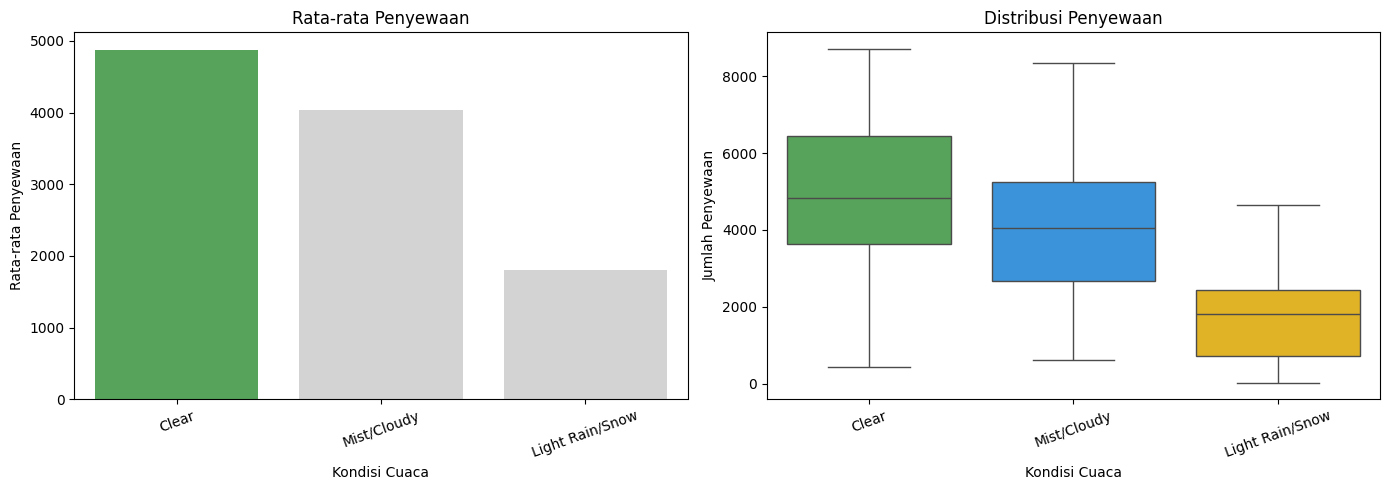

In [20]:
# Mapping label cuaca
weather_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day_df['weather_label'] = day_df['weather_situation'].map(weather_map)

# Hitung rata-rata untuk barplot
weather_avg = day_df.groupby("weather_label")["total_rentals"].mean().reset_index()
weather_avg = weather_avg.sort_values(by="total_rentals", ascending=False)

# Warna untuk barplot (highlight tertinggi)
max_val = weather_avg["total_rentals"].max()
bar_colors = ["#4CAF50" if val == max_val else "#D3D3D3" for val in weather_avg["total_rentals"]]

# Warna untuk boxplot
palette_colors = {
    'Clear': '#4CAF50',
    'Mist/Cloudy': '#2196F3',
    'Light Rain/Snow': '#FFC107',
    'Heavy Rain/Snow': '#F44336'
}

# Subplot
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Barplot
sns.barplot(
    data=weather_avg,
    x='weather_label',
    y='total_rentals',
    palette=bar_colors,
    ax=ax[0]
)
ax[0].set_title('Rata-rata Penyewaan')
ax[0].set_xlabel('Kondisi Cuaca')
ax[0].set_ylabel('Rata-rata Penyewaan')
ax[0].tick_params(axis='x', rotation=20)

# Boxplot
sns.boxplot(
    data=day_df,
    x='weather_label',
    y='total_rentals',
    palette=palette_colors,
    ax=ax[1]
)
ax[1].set_title('Distribusi Penyewaan')
ax[1].set_xlabel('Kondisi Cuaca')
ax[1].set_ylabel('Jumlah Penyewaan')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insight:**

- Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda selama periode 2011–2012.
- Pada kondisi cuaca cerah (Clear), rata-rata jumlah penyewaan sepeda merupakan yang tertinggi, yaitu mendekati 5000 penyewaan per hari. Ketika kondisi cuaca berubah menjadi berkabut atau berawan (Mist/Cloudy), jumlah penyewaan mengalami penurunan menjadi sekitar 4000. Penurunan paling drastis terjadi pada kondisi cuaca buruk seperti hujan ringan atau salju (Light Rain/Snow), di mana rata-rata penyewaan hanya sekitar 1800.
- Dari boxplot, terlihat bahwa:
  - Pada cuaca cerah, distribusi penyewaan lebih tinggi dan memiliki rentang yang luas, menunjukkan aktivitas penggunaan yang tinggi dan bervariasi.
  - Pada cuaca buruk, distribusi penyewaan cenderung lebih rendah dan sempit, menandakan penggunaan sepeda yang terbatas.
- Secara keseluruhan, semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda. Hal ini menunjukkan bahwa cuaca merupakan faktor utama yang memengaruhi keputusan pengguna dalam menyewa sepeda.
- Untuk meningkatkan jumlah penyewaan, dapat dilakukan strategi promosi atau diskon pada saat kondisi cuaca kurang baik, seperti saat berkabut atau hujan ringan, agar tetap menarik minat pengguna. Selain itu, penyedia layanan dapat menyesuaikan jumlah ketersediaan sepeda berdasarkan prediksi cuaca, dengan menyediakan lebih banyak sepeda pada saat cuaca cerah untuk memaksimalkan keuntungan.
- Penyedia juga dapat mengembangkan fitur informasi cuaca atau rekomendasi waktu terbaik untuk bersepeda guna meningkatkan kenyamanan dan pengalaman pengguna.

### Pertanyaan 2: Pada bulan dan musim apa jumlah penyewaan sepeda paling tinggi selama periode 2011–2012?


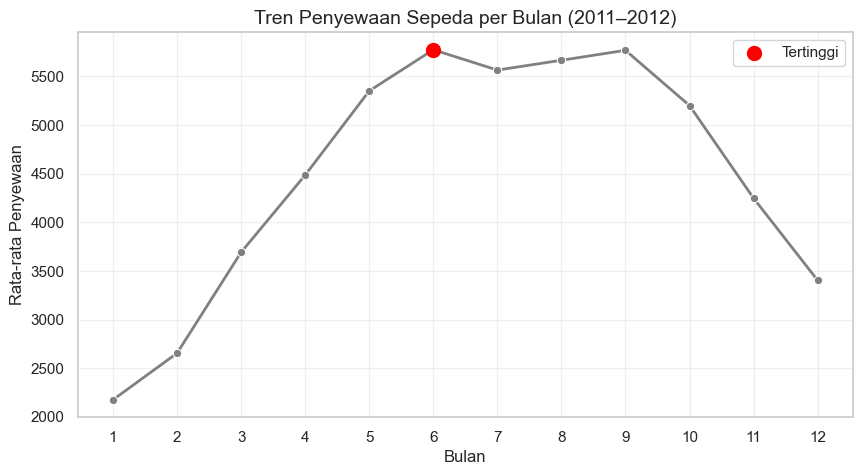

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5616\1849353451.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


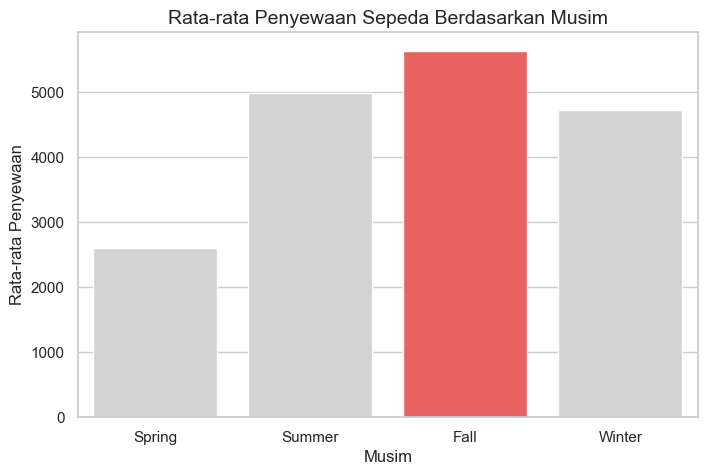

In [21]:
sns.set(style="whitegrid")

season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

day_df["season_label"] = day_df["season"].map(season_map)

# ======================
# LINEPLOT (per bulan)
# ======================
monthly_avg = day_df.groupby("month")["total_rentals"].mean().reset_index()

# cari titik tertinggi
max_val = monthly_avg["total_rentals"].max()
max_month = monthly_avg.loc[monthly_avg["total_rentals"].idxmax(), "month"]

plt.figure(figsize=(10,5))

# line utama (abu-abu)
sns.lineplot(
    data=monthly_avg,
    x='month',
    y='total_rentals',
    marker='o',
    color='gray',
    linewidth=2
)

# highlight titik tertinggi
plt.scatter(max_month, max_val, color='red', s=100, zorder=5, label='Tertinggi')

plt.title('Tren Penyewaan Sepeda per Bulan (2011–2012)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ======================
# BARPLOT (per musim)
# ======================
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

season_avg = day_df.groupby("season_label")["total_rentals"].mean().reindex(season_order).reset_index()

# cari tertinggi
max_val = season_avg["total_rentals"].max()

# warna: abu semua, kecuali tertinggi
colors = ["#FF4C4C" if val == max_val else "#D3D3D3" for val in season_avg["total_rentals"]]

plt.figure(figsize=(8,5))

sns.barplot(
    data=season_avg,
    x='season_label',
    y='total_rentals',
    palette=colors
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim', fontsize=14)
plt.xlabel('Musim')
plt.ylabel('Rata-rata Penyewaan')

plt.show()

**Insight:**

- Jumlah penyewaan sepeda menunjukkan pola yang meningkat dari awal tahun dan mencapai puncaknya pada bulan Juni dengan rata-rata sekitar 5800 penyewaan, yang menandakan tingginya aktivitas bersepeda pada pertengahan tahun.
- Setelah mencapai puncak, penyewaan cenderung stabil pada bulan Juli hingga September sebelum akhirnya mengalami penurunan hingga sekitar 3400 pada bulan Desember, yang mengindikasikan penurunan minat di akhir tahun.
- Berdasarkan musim, penyewaan sepeda tertinggi terjadi pada musim Fall dengan rata-rata sekitar 5600 penyewaan, diikuti oleh Summer sekitar 5000 penyewaan, sedangkan Spring menjadi yang terendah dengan sekitar 2600 penyewaan. Hal ini menunjukkan bahwa kondisi musim yang lebih nyaman sangat memengaruhi peningkatan jumlah penyewaan sepeda dibandingkan musim dengan kondisi yang kurang mendukung.
- Untuk meningkatkan jumlah penyewaan, dapat dilakukan strategi promosi pada periode dengan penyewaan rendah seperti awal tahun (Januari–Maret) dan akhir tahun (November–Desember) agar permintaan lebih merata sepanjang tahun.
Selain itu, pada periode dengan penyewaan tinggi seperti bulan Juni serta musim Fall dan Summer, dapat diterapkan strategi penyesuaian harga atau peningkatan ketersediaan sepeda untuk memaksimalkan keuntungan.

### Pertanyaan 3: Bagaimana perbedaan pola penyewaan sepeda antara hari kerja dan akhir pekan berdasarkan jumlah pengguna (casual vs registered)?

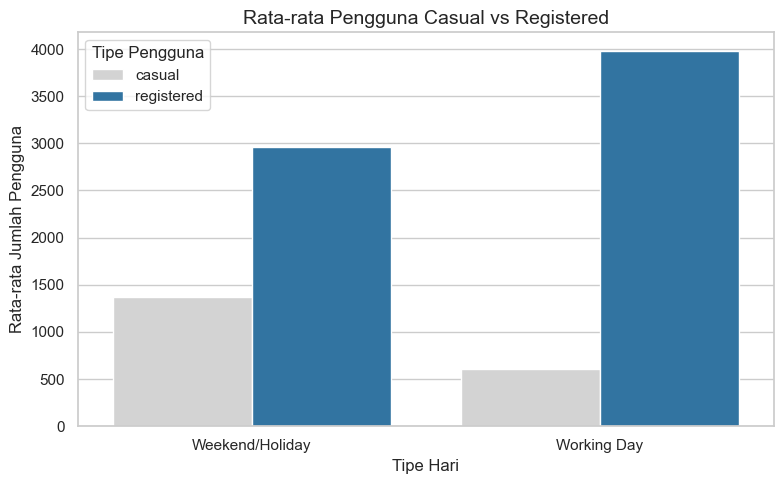

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5616\1361637027.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


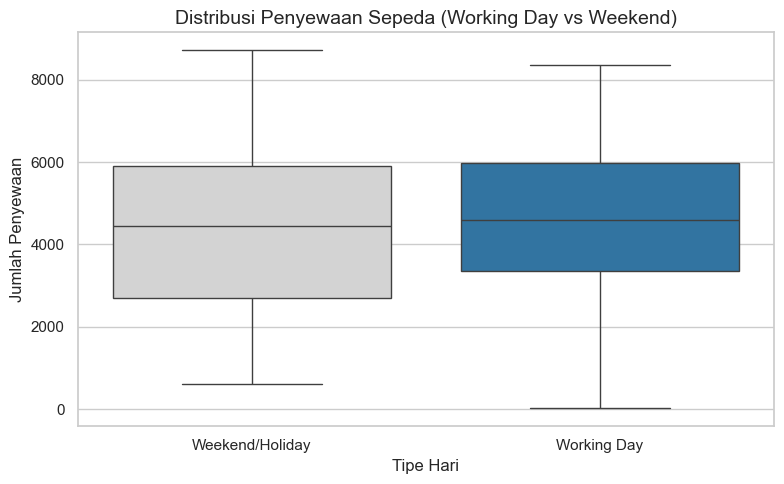

In [22]:
sns.set(style="whitegrid")

# Mapping label
day_df['day_type'] = day_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

# ======================
# BARPLOT (Casual vs Registered)
# ======================
user_day_group = day_df.groupby('day_type')[['casual', 'registered']].mean().reset_index()

# Ubah ke format panjang
user_day_melt = user_day_group.melt(id_vars='day_type',
                                   var_name='user_type',
                                   value_name='avg_users')

plt.figure(figsize=(8,5))

sns.barplot(
    data=user_day_melt,
    x='day_type',
    y='avg_users',
    hue='user_type',
    palette={
        'casual': '#D3D3D3',      # netral
        'registered': '#1F77B4'   # highlight (biru)
    }
)

plt.title('Rata-rata Pengguna Casual vs Registered', fontsize=14)
plt.xlabel('Tipe Hari')
plt.ylabel('Rata-rata Jumlah Pengguna')
plt.legend(title='Tipe Pengguna')

plt.tight_layout()
plt.show()


# ======================
# BOXPLOT (Total Rentals)
# ======================
plt.figure(figsize=(8,5))

sns.boxplot(
    data=day_df,
    x='day_type',
    y='total_rentals',
    palette={
        'Weekend/Holiday': '#D3D3D3',
        'Working Day': '#1F77B4'
    }
)

plt.title('Distribusi Penyewaan Sepeda (Working Day vs Weekend)', fontsize=14)
plt.xlabel('Tipe Hari')
plt.ylabel('Jumlah Penyewaan')

plt.tight_layout()
plt.show()

**Insight:**
- Terdapat perbedaan pola penyewaan sepeda yang cukup jelas antara hari kerja dan akhir pekan berdasarkan tipe pengguna.
- Pengguna registered memiliki jumlah penyewaan yang lebih tinggi dibandingkan pengguna casual baik pada hari kerja maupun akhir pekan. Pada hari kerja, rata-rata pengguna registered mencapai sekitar 4000, sedangkan pada akhir pekan sekitar 2900. Sebaliknya, pengguna casual lebih banyak melakukan penyewaan pada akhir pekan dengan rata-rata sekitar 1300, dibandingkan hari kerja yang hanya sekitar 600. Hal ini menunjukkan bahwa pengguna registered cenderung menggunakan sepeda untuk kebutuhan rutin seperti bekerja, sedangkan pengguna casual lebih banyak menggunakan sepeda untuk rekreasi di akhir pekan.
- Dari boxplot, terlihat bahwa:
  - Distribusi penyewaan pada hari kerja memiliki median yang sedikit lebih tinggi dibandingkan akhir pekan, menunjukkan aktivitas yang lebih konsisten.
  - Pada akhir pekan, distribusi penyewaan cenderung lebih bervariasi, yang mengindikasikan penggunaan yang lebih fleksibel dan dipengaruhi oleh waktu luang.
- Secara keseluruhan, hari kerja didominasi oleh pengguna registered dengan pola penggunaan yang stabil, sedangkan akhir pekan didominasi peningkatan pengguna casual dengan pola yang lebih fluktuatif.
- Untuk meningkatkan jumlah penyewaan, dapat dilakukan strategi promosi khusus bagi pengguna casual pada akhir pekan, seperti paket sewa harian atau diskon rekreasi untuk menarik lebih banyak pengguna. Selain itu, pada hari kerja dapat difokuskan pada peningkatan layanan bagi pengguna registered, seperti sistem langganan atau membership untuk mempertahankan pengguna tetap.
- Penyedia layanan juga dapat menyesuaikan jumlah sepeda dan distribusinya, dengan menyediakan lebih banyak sepeda di area perkantoran pada hari kerja dan di area wisata pada akhir pekan.

## Analisis Lanjutan: Clustering Jumlah Penyewaan



### Berapa banyak hari yang termasuk dalam kategori penyewaan sepeda rendah, sedang, dan tinggi selama periode analisis?

Pada analisis lanjutan, digunakan teknik kategorisasi untuk mengelompokkan jumlah penyewaan sepeda. Tujuan dari pendekatan ini adalah membagi tingkat penyewaan ke dalam tiga kategori utama, yaitu rendah, sedang, dan tinggi. Adapun kriteria yang digunakan adalah sebagai berikut:

- Penyewaan rendah jika jumlahnya kurang dari 3000 penyewaan/hari
- Penyewaan sedang jika berkisar 3001-5000 penyewaan/hari
- Penyewaan tinggi jika melebihi 5000 penyewaan/hari

Pendekatan ini dipilih karena jumlah penyewaan sepeda merupakan variabel numerik dengan variasi yang cukup besar setiap harinya. Dengan melakukan pengelompokan ini, pola penyewaan dapat lebih mudah dipahami serta membantu dalam menyederhanakan interpretasi data tanpa menghilangkan informasi yang penting.

Kategori_Penyewaan
Tinggi    286
Sedang    273
Rendah    172
Name: count, dtype: int64

Kategori yang paling banyak harinya adalah: Tinggi

Contoh Data Setelah Clustering
   total_rentals Kategori_Penyewaan
0            985             Rendah
1            801             Rendah
2           1349             Rendah
3           1562             Rendah
4           1600             Rendah

Visualisasi distribusi kategori penyewaan


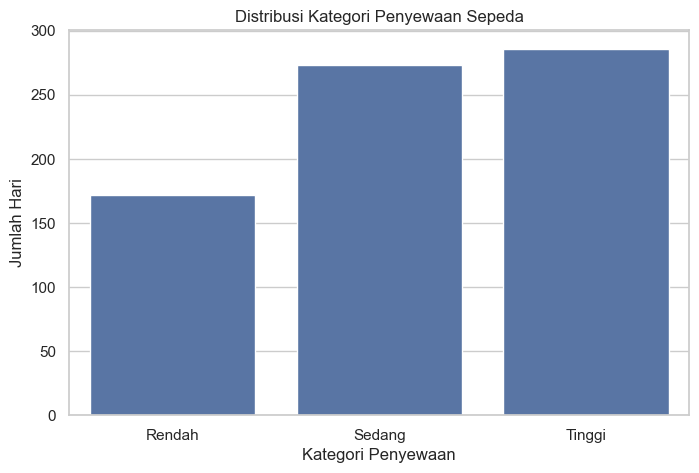

In [23]:
def categorize_rentals(total_rentals):
    if total_rentals <= 3000:
        return 'Rendah'
    elif 3001 <= total_rentals <= 5000:
        return 'Sedang'
    else:
        return 'Tinggi'


day_df['Kategori_Penyewaan'] = day_df['total_rentals'].apply(categorize_rentals)
category_counts = day_df['Kategori_Penyewaan'].value_counts()

print(category_counts)

most_frequent_category = category_counts.idxmax()
print(f"\nKategori yang paling banyak harinya adalah: {most_frequent_category}")

print("\nContoh Data Setelah Clustering")
print(day_df[['total_rentals', 'Kategori_Penyewaan']].head())

print("\nVisualisasi distribusi kategori penyewaan")
plt.figure(figsize=(8,5))
sns.countplot(data=day_df, x='Kategori_Penyewaan')
plt.title('Distribusi Kategori Penyewaan Sepeda')
plt.xlabel('Kategori Penyewaan')
plt.ylabel('Jumlah Hari')
plt.show()


**Insight:**

- Berdasarkan hasil kategorisasi dengan batas rendah (<3000), sedang (3001–5000), dan tinggi (>5000), sebagian besar hari berada dalam kategori penyewaan tinggi dengan jumlah 286 hari, diikuti kategori sedang sebanyak 273 hari, dan rendah sebanyak 172 hari.
Hal ini menunjukkan bahwa mayoritas hari memiliki jumlah penyewaan di atas 5000, sehingga aktivitas penyewaan sepeda cenderung berada pada tingkat yang tinggi selama periode analisis.
- Selisih antara kategori tinggi dan sedang yang tidak terlalu jauh mengindikasikan bahwa penyewaan sepeda cukup konsisten berada pada rentang menengah hingga tinggi (3001-5000). Jumlah hari dengan kategori rendah (<3000) yang lebih sedikit menunjukkan bahwa kondisi permintaan rendah relatif jarang terjadi.
- Secara keseluruhan, distribusi ini menunjukkan bahwa layanan penyewaan sepeda memiliki tingkat penggunaan yang stabil dan didominasi oleh permintaan tinggi, sehingga memiliki potensi yang baik untuk pengembangan layanan.
Untuk meningkatkan performa, strategi dapat difokuskan pada hari dengan kategori rendah (<3000), misalnya dengan memberikan promo atau insentif guna meningkatkan jumlah penyewaan.
Selain itu, pada hari dengan kategori tinggi (>5000), penyedia layanan perlu memastikan ketersediaan sepeda dan kualitas layanan tetap optimal agar mampu memenuhi tingginya permintaan.

### Bagaimana distribusi kategori penyewaan sepeda berdasarkan kondisi cuaca selama periode analisis?

Untuk memahami faktor yang memengaruhi kategori penyewaan sepeda, dilakukan analisis hubungan antara kondisi cuaca dan kategori penyewaan. Tujuan dari analisis ini adalah untuk melihat bagaimana distribusi kategori penyewaan sepeda (rendah, sedang, dan tinggi) pada setiap kondisi cuaca yang berbeda.

Pendekatan ini digunakan karena kondisi cuaca merupakan salah satu faktor eksternal yang dapat memengaruhi aktivitas pengguna dalam menyewa sepeda. Dengan melakukan analisis ini, dapat diketahui pola kecenderungan penyewaan pada kondisi cuaca tertentu sehingga memudahkan dalam memahami perilaku pengguna berdasarkan faktor lingkungan.

Distribusi Kategori Penyewaan Berdasarkan Cuaca:
Kategori_Penyewaan  Rendah  Sedang  Tinggi
weather_label                             
Clear                   78     171     214
Mist/Cloudy             75     100      72
Light Rain/Snow         19       2       0


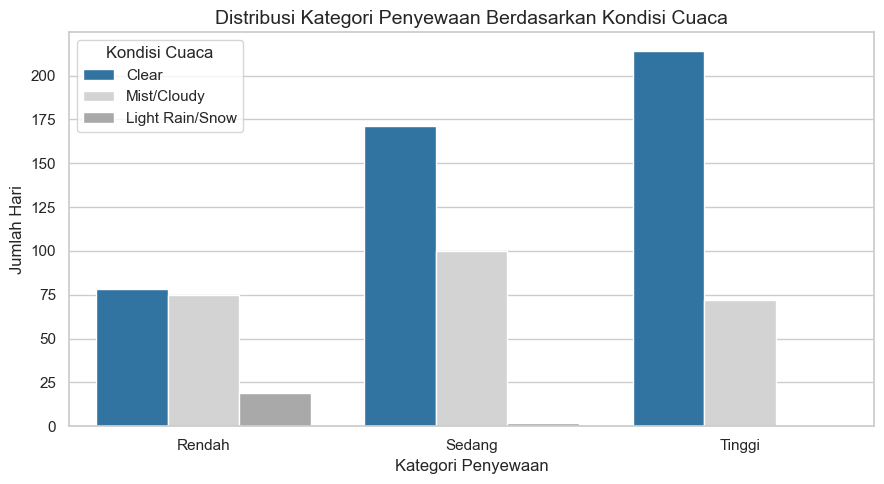

In [24]:
sns.set(style="whitegrid")

# ======================
# Mapping label cuaca
# ======================
weather_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day_df['weather_label'] = day_df['weather_situation'].map(weather_map)

# Urutan kategori biar konsisten
category_order = ['Rendah', 'Sedang', 'Tinggi']

# ======================
# Crosstab (biar lebih rapi analisisnya)
# ======================
weather_category = pd.crosstab(
    day_df['weather_label'],
    day_df['Kategori_Penyewaan']
)

print("Distribusi Kategori Penyewaan Berdasarkan Cuaca:")
print(weather_category)

# ======================
# Visualisasi (Countplot)
# ======================
plt.figure(figsize=(9,5))

sns.countplot(
    data=day_df,
    x='Kategori_Penyewaan',
    hue='weather_label',
    order=category_order,
    palette={
        'Clear': '#1F77B4',            # highlight utama
        'Mist/Cloudy': '#D3D3D3',
        'Light Rain/Snow': '#A9A9A9',
        'Heavy Rain/Snow': '#808080'
    }
)

plt.title('Distribusi Kategori Penyewaan Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kategori Penyewaan')
plt.ylabel('Jumlah Hari')

plt.legend(title='Kondisi Cuaca')
plt.tight_layout()

plt.show()

**Insight:**

- Distribusi kategori penyewaan menunjukkan bahwa pada kondisi cuaca cerah (Clear), jumlah hari dengan kategori penyewaan tinggi (214 hari) merupakan yang paling dominan, diikuti kategori sedang (171 hari) dan rendah (78 hari). Hal ini menunjukkan bahwa cuaca cerah sangat mendukung tingginya aktivitas penyewaan sepeda.
- Pada kondisi Mist/Cloudy, distribusi penyewaan cenderung lebih merata, dengan kategori sedang (100 hari) lebih dominan dibandingkan tinggi (72 hari) dan rendah (75 hari). Hal ini mengindikasikan bahwa cuaca yang kurang optimal mulai menurunkan intensitas penyewaan.
- Pada kondisi Light Rain/Snow, hampir seluruh hari berada pada kategori penyewaan rendah (19 hari), dengan sangat sedikit kategori sedang (2 hari) dan tidak terdapat kategori tinggi. Hal ini menunjukkan bahwa cuaca buruk sangat membatasi aktivitas penyewaan sepeda.
- Secara keseluruhan, semakin baik kondisi cuaca, semakin besar kemungkinan penyewaan sepeda berada pada kategori tinggi, sedangkan pada cuaca buruk, penyewaan cenderung berada pada kategori rendah. Hal ini menegaskan bahwa cuaca merupakan faktor penting dalam menentukan tingkat penyewaan sepeda.
- Untuk meningkatkan jumlah penyewaan, dapat dilakukan strategi seperti menyediakan promo atau insentif pada kondisi cuaca kurang baik (misalnya berkabut atau hujan ringan) untuk menarik minat pengguna. Selain itu, pada kondisi cuaca cerah, penyedia layanan perlu memastikan ketersediaan sepeda dalam jumlah yang cukup agar dapat memenuhi permintaan yang tinggi dan memaksimalkan keuntungan.

## Conclusion

Berdasarkan hasil analisis, dapat disimpulkan sebagai berikut.
- Kondisi cuaca memiliki pengaruh besar terhadap jumlah penyewaan sepeda, di mana cuaca cerah menghasilkan penyewaan tertinggi, sedangkan cuaca berkabut menurunkan penyewaan dan cuaca buruk seperti hujan ringan atau salju menyebabkan penurunan yang signifikan hingga ke kategori rendah.  
- Dari segi waktu, penyewaan sepeda mencapai puncaknya pada bulan Juni dan cenderung tinggi pada musim Fall dan Summer, sedangkan pada awal dan akhir tahun seperti bulan Januari dan Desember mengalami penurunan karena kondisi yang kurang mendukung.  
- Pola penyewaan berdasarkan tipe hari menunjukkan bahwa hari kerja didominasi oleh pengguna registered dengan aktivitas yang stabil, sedangkan pada akhir pekan terjadi peningkatan pengguna casual yang lebih bersifat rekreasi.  
- Berdasarkan hasil clustering, sebagian besar hari termasuk dalam kategori penyewaan tinggi (>5000), yang menunjukkan bahwa secara umum permintaan penyewaan sepeda berada pada tingkat yang tinggi dan relatif stabil.  
- Distribusi kategori penyewaan berdasarkan cuaca menunjukkan bahwa kategori tinggi didominasi oleh cuaca cerah, sedangkan pada cuaca buruk hampir seluruh penyewaan berada pada kategori rendah, sehingga cuaca menjadi faktor utama dalam menentukan tingkat penyewaan.  

**Kesimpulan Akhir**
Dari hasil analisis ini, dapat disimpulkan bahwa pola penyewaan sepeda sangat dipengaruhi oleh faktor cuaca, musim, waktu, dan tipe hari. Kondisi yang nyaman seperti cuaca cerah, pertengahan tahun, dan hari kerja mendorong peningkatan penyewaan, sedangkan kondisi yang kurang mendukung menyebabkan penurunan aktivitas. Dengan memahami pola ini, penyedia layanan dapat menyusun strategi yang lebih efektif untuk meningkatkan jumlah penyewaan sepeda.  

**Strategi Bisnis**
- Mengoptimalkan ketersediaan sepeda pada kondisi dengan permintaan tinggi seperti cuaca cerah, bulan pertengahan tahun, dan hari kerja untuk memaksimalkan keuntungan.  
- Menerapkan strategi promosi atau diskon pada kondisi dengan permintaan rendah seperti cuaca buruk, awal dan akhir tahun, agar permintaan lebih merata.  
- Mengembangkan program membership atau langganan untuk mempertahankan pengguna registered yang dominan pada hari kerja.  
- Menyediakan paket rekreasi atau promo khusus pada akhir pekan untuk menarik lebih banyak pengguna casual.  
- Memanfaatkan prediksi cuaca dan pola musiman untuk mengatur distribusi sepeda secara lebih efisien dan menghindari kekurangan atau kelebihan unit di lokasi tertentu.  

**Simpan Hasil**

In [25]:
day_df.to_csv('data_day.csv', index=False)